## Data Preprocessing

In [1]:
import sys
!"{sys.executable}" -m pip install matplotlib
!"{sys.executable}" -m pip install seaborn
!"{sys.executable}" -m pip install networkx

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

### Loading and Filtering Training Data

In [3]:
df = pd.read_csv("delivery_data.csv")
print(f'Total rows: {len(df):,}')
print(f'Data split: {df["data"].value_counts().to_dict()}')
df = df[df["data"] == "training"].copy()
df.head()

Total rows: 144,867
Data split: {'training': 104858, 'test': 40009}


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [4]:
df.dtypes

data                               object
trip_creation_time                 object
route_schedule_uuid                object
route_type                         object
trip_uuid                          object
source_center                      object
source_name                        object
destination_center                 object
destination_name                   object
od_start_time                      object
od_end_time                        object
start_scan_to_end_scan            float64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                   object
actual_distance_to_destination    float64
actual_time                       float64
osrm_time                         float64
osrm_distance                     float64
factor                            float64
segment_actual_time               float64
segment_osrm_time                 float64
segment_osrm_distance             float64
segment_factor                    

### Converting to Datetime Format

In [5]:
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["od_start_time"] = pd.to_datetime(df["od_start_time"])
df["od_end_time"] = pd.to_datetime(df["od_end_time"])
df["cutoff_timestamp"] = pd.to_datetime(df["cutoff_timestamp"], format="mixed")

df['hour_of_day'] = df['od_start_time'].dt.hour
df['day_of_week'] = df['od_start_time'].dt.dayofweek
df['is_night'] = df['hour_of_day'].between(20, 6)
df["hour"] = df["trip_creation_time"].dt.hour

### Handling Missing Values

In [6]:
df.isnull().any()

data                              False
trip_creation_time                False
route_schedule_uuid               False
route_type                        False
trip_uuid                         False
source_center                     False
source_name                        True
destination_center                False
destination_name                   True
od_start_time                     False
od_end_time                       False
start_scan_to_end_scan            False
is_cutoff                         False
cutoff_factor                     False
cutoff_timestamp                  False
actual_distance_to_destination    False
actual_time                       False
osrm_time                         False
osrm_distance                     False
factor                            False
segment_actual_time               False
segment_osrm_time                 False
segment_osrm_distance             False
segment_factor                    False
hour_of_day                       False


In [7]:
print(df["source_name"].isnull().sum())
print(df["destination_name"].isnull().sum())

129
100


In [8]:
df['source_name'] = df['source_name'].fillna(df['source_center'])
df['destination_name'] = df['destination_name'].fillna(df['destination_center'])

### Handling Outliers

In [9]:
df["is_outlier"] = (df["segment_factor"] > 50) | (df["segment_factor"] < 0)
df["factor_capped"] = df['factor'].clip(upper=df['factor'].quantile(0.99))
df["segment_factor_capped"] = df['segment_factor'].clip(lower=0, upper=df['segment_factor'].quantile(0.99))

In [10]:
# Filtering out outliers
df = df[~df['is_outlier']].copy()
print(f'Rows used for graph (after removing outliers): {len(df):,}')

Rows used for graph (after removing outliers): 103,014


### Feature Engineering

In [11]:
# Time gap
df["time_gap"] = df["actual_time"] - df["osrm_time"]

# Distance efficiency
df["distance_efficiency"] = df["actual_distance_to_destination"]/df["osrm_distance"]

# Chronically delayed segment
df['is_delayed'] = df['segment_factor'] > 1.2

# Total duration
df['trip_duration'] = (df['od_end_time'] - df['od_start_time']).dt.total_seconds()/60

# Corridor (source to destination)
df["corridor"] = (df["source_center"].astype(str) + "→" + df["destination_center"].astype(str))

In [12]:
# Delay stats
print(f'Clean rows: {len(df):,}')
print(f'Route types found: {df["route_type"].unique().tolist()}')
print(f'Delayed trips: {df["is_delayed"].sum():,} ({df["is_delayed"].mean()*100:.1f}%)')
print()
print('Segment Delay Ratio Stats:')
print(df['segment_factor'].describe().round(3))

Clean rows: 103,014
Route types found: ['Carting', 'FTL']
Delayed trips: 86,956 (84.4%)

Segment Delay Ratio Stats:
count    103014.000
mean          2.155
std           2.221
min           0.000
25%           1.367
50%           1.692
75%           2.250
max          50.000
Name: segment_factor, dtype: float64


## EDA

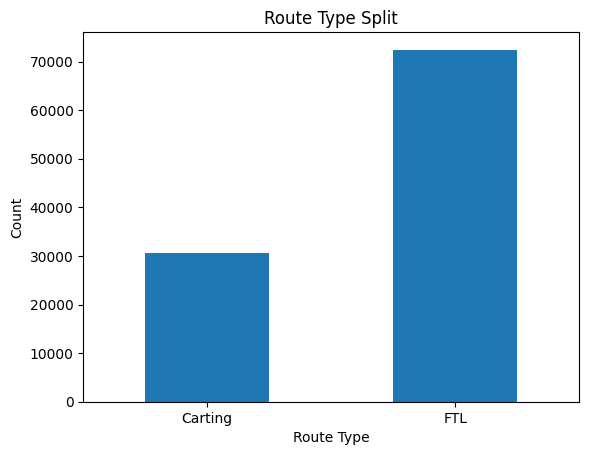

In [13]:
## Route Type Distribution
df.groupby("route_type").size().plot(kind="bar")
plt.title("Route Type Split")
plt.xlabel("Route Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

(array([0, 1]), [Text(0, 0, 'Carting'), Text(1, 0, 'FTL')])

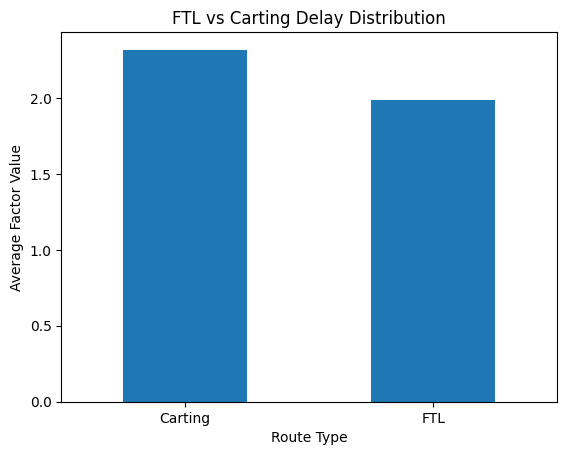

In [14]:
## FTL vs Carting Delay Distribution
df.groupby("route_type")["factor"].mean().plot(kind = "bar")
plt.title("FTL vs Carting Delay Distribution")
plt.xlabel("Route Type")
plt.ylabel("Average Factor Value")
plt.xticks(rotation=0)

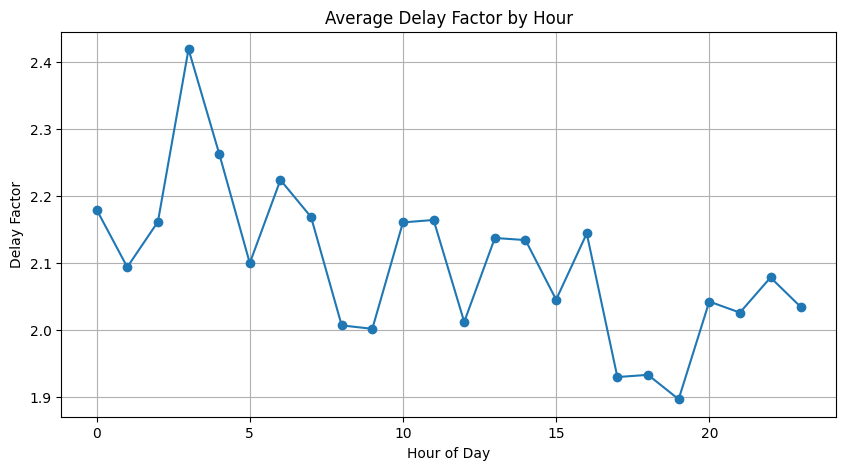

In [15]:
## Average delay factor by hour of day
hourly_delay = df.groupby("hour")["factor"].mean()
plt.figure(figsize=(10,5))
hourly_delay.plot(marker="o")
plt.title("Average Delay Factor by Hour")
plt.ylabel("Delay Factor")
plt.xlabel("Hour of Day")
plt.grid(True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'IND000000ACB'),
  Text(1, 0, 'IND562132AAA'),
  Text(2, 0, 'IND421302AAG'),
  Text(3, 0, 'IND411033AAA'),
  Text(4, 0, 'IND501359AAE'),
  Text(5, 0, 'IND160002AAC'),
  Text(6, 0, 'IND712311AAA'),
  Text(7, 0, 'IND395023AAA'),
  Text(8, 0, 'IND560099AAB'),
  Text(9, 0, 'IND110037AAM')])

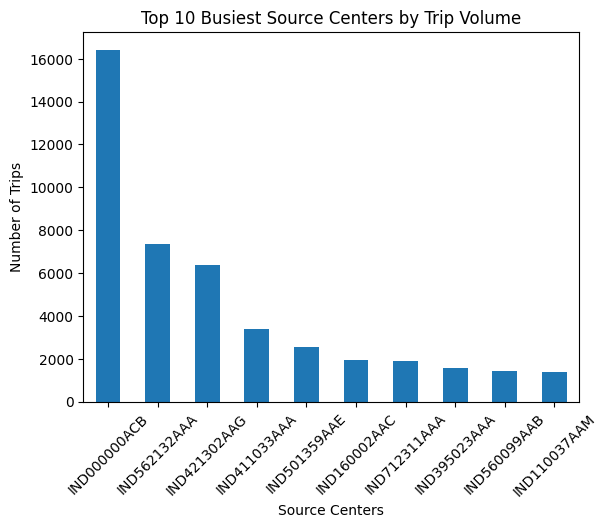

In [16]:
## Top 10 busiest source centers
top_10 = df.groupby("source_center").size().sort_values(ascending = False).head(10)
top_10.plot(kind = "bar")
plt.title("Top 10 Busiest Source Centers by Trip Volume")
plt.xlabel("Source Centers")
plt.ylabel("Number of Trips")
plt.xticks(rotation = 45)

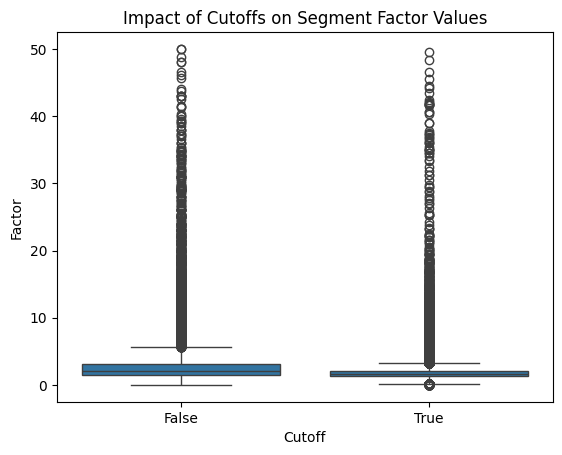

In [17]:
## Impact of cutoff on factors
sns.boxplot(x = df["is_cutoff"], y = df["segment_factor"])
plt.title("Impact of Cutoffs on Segment Factor Values")
plt.xlabel("Cutoff")
plt.ylabel("Factor")
plt.show()

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Gurgaon_Bilaspur_HB (Haryana)'),
  Text(1, 0, 'Bangalore_Nelmngla_H (Karnataka)'),
  Text(2, 0, 'Bhiwandi_Mankoli_HB (Maharashtra)'),
  Text(3, 0, 'Hyderabad_Shamshbd_H (Telangana)'),
  Text(4, 0, 'Kolkata_Dankuni_HB (West Bengal)'),
  Text(5, 0, 'Pune_Tathawde_H (Maharashtra)'),
  Text(6, 0, 'Delhi_Airport_H (Delhi)'),
  Text(7, 0, 'Sonipat_Kundli_H (Haryana)'),
  Text(8, 0, 'Bhubaneshwar_Hub (Orissa)'),
  Text(9, 0, 'Chandigarh_Mehmdpur_H (Punjab)')])

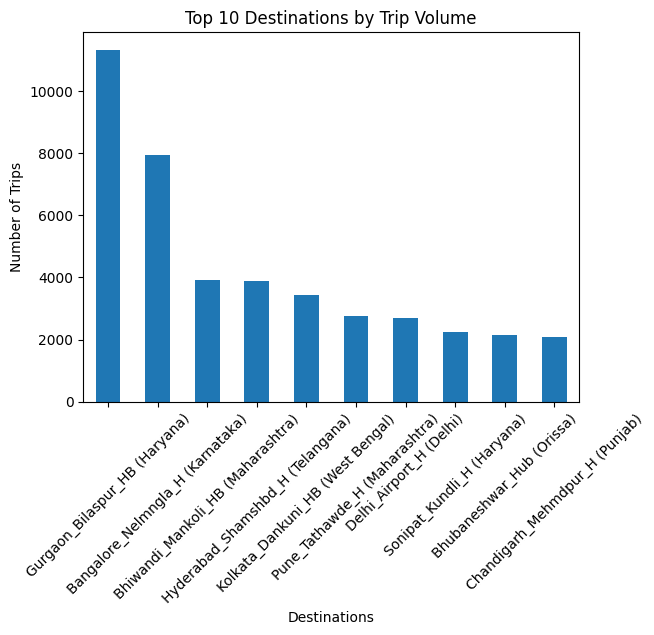

In [18]:
## Top destinations (nodes)
df.groupby("destination_name").size().sort_values(ascending = False).head(10).plot(kind = "bar")
plt.title("Top 10 Destinations by Trip Volume")
plt.xlabel("Destinations")
plt.ylabel("Number of Trips")
plt.xticks(rotation = 45)

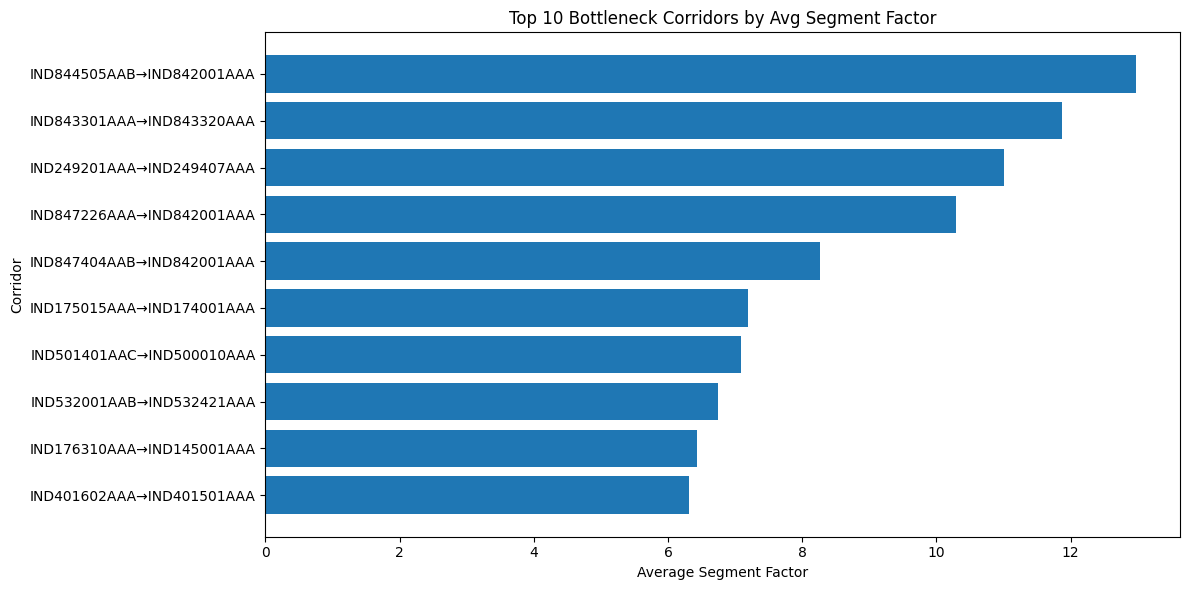

                       corridor  avg_segment_factor  trip_count
2454  IND844505AAB→IND842001AAA           12.979239          11
2450  IND843301AAA→IND843320AAA           11.877529          13
517   IND249201AAA→IND249407AAA           11.000178          12
2467  IND847226AAA→IND842001AAA           10.284376          14
2468  IND847404AAB→IND842001AAA            8.267355          13
343   IND175015AAA→IND174001AAA            7.187700          13
1297  IND501401AAC→IND500010AAA            7.089448          10
1487  IND532001AAB→IND532421AAA            6.749839          13
352   IND176310AAA→IND145001AAA            6.430136          13
928   IND401602AAA→IND401501AAA            6.319672          10


In [19]:
## Top 10 Bottleneck Corridors by Average Segment Factor
### Calculate average segment factor and trip count for each corridor
corridor_stats = (df.groupby("corridor").agg(avg_segment_factor=("segment_factor", "mean"), trip_count=("trip_uuid", "nunique")).reset_index())

### Keep only corridors with at least 10 trips
corridor_stats = corridor_stats[corridor_stats["trip_count"] >= 10]

### Get top 10 bottlenecks
top_corridors = (corridor_stats.sort_values("avg_segment_factor", ascending=False).head(10))

plt.figure(figsize=(12, 6))
plt.barh(top_corridors["corridor"], top_corridors["avg_segment_factor"])
plt.xlabel("Average Segment Factor")
plt.ylabel("Corridor")
plt.title("Top 10 Bottleneck Corridors by Avg Segment Factor")

plt.gca().invert_yaxis()  # highest value on top
plt.tight_layout()
plt.show()

# Display values
print(top_corridors)

In [20]:
# Saving the final df
df.to_csv("final_delivery_data.csv", index = False)